# Resilient & resumable sweeps

A long `method × seed` sweep should not throw away hours of good runs because
one cell hit a transient failure — and it must never let you compute statistics
on a grid with holes. mushin gives you **fail-soft** runs (`on_error="nan"`),
a **manifest**, and **resume**. This notebook walks the full loop end to end.

In [ ]:
from __future__ import annotations

import json
import tempfile
from pathlib import Path

import torch

from mushin import multirun
from mushin.benchmark import IncompleteSweepError, compare_methods
from mushin.workflows import MultiRunMetricsWorkflow

One stable working directory for the whole notebook, plus a sentinel file that
stands in for "we fixed the root cause". The `mlp / seed=3` cell fails until the
sentinel exists.

In [ ]:
WORK = Path(tempfile.mkdtemp())
SENTINEL = WORK / "cause_fixed.flag"


class FlakySweep(MultiRunMetricsWorkflow):
    @staticmethod
    def task(method: str, seed: int) -> dict:
        if method == "mlp" and seed == 3 and not SENTINEL.exists():
            raise RuntimeError("simulated transient failure on mlp/seed=3")
        torch.manual_seed(seed)
        base = 0.90 if method == "cnn" else 0.82
        return dict(accuracy=base + 0.01 * torch.rand(1).item())

## 1. Fail-soft: `on_error="nan"`

The bad cell becomes `NaN`, a warning is emitted, and every other cell finishes.

In [ ]:
wf = FlakySweep()
wf.run(
    method=multirun(["cnn", "mlp"]),
    seed=multirun([0, 1, 2, 3, 4]),
    working_dir=str(WORK),
    on_error="nan",
)
print("is_complete:", wf.is_complete)
wf.failures

[2026-07-14 20:39:27,464][HYDRA] Launching 10 jobs locally


[2026-07-14 20:39:27,465][HYDRA] 	#0 : +method=cnn +seed=0


[2026-07-14 20:39:27,531][HYDRA] 	#1 : +method=cnn +seed=1


[2026-07-14 20:39:27,594][HYDRA] 	#2 : +method=cnn +seed=2


[2026-07-14 20:39:27,655][HYDRA] 	#3 : +method=cnn +seed=3


...

[2026-07-14 20:39:28,046][HYDRA] 	#8 : +method=mlp +seed=3


[2026-07-14 20:39:28,106][HYDRA] 	#9 : +method=mlp +seed=4


is_complete: False


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  r

[{'combo': 'method=mlp,seed=3',
  'exception': "RuntimeError('simulated transient failure on mlp/seed=3')",
  'working_dir': '/var/folders/y9/wzls976d3f9074y29dbrygw80000gn/T/tmpjubxikd8/8'}]

The grid has exactly one hole:

In [ ]:
ds_before = wf.to_xarray()
ds_before["accuracy"]

<xarray.DataArray 'accuracy' (method: 2, seed: 5)> Size: 80B
array([[0.90496257, 0.90757632, 0.90614695, 0.90004264, 0.90559639],
       [0.82496257, 0.82757632, 0.82614695,        nan, 0.82559639]])
Coordinates:
  * method   (method) <U3 24B 'cnn' 'mlp'
  * seed     (seed) int64 40B 0 1 2 3 4

Every requested cell's status is recorded in the sweep manifest — this is what
makes a resume possible. The manifest maps each combo to its status
(`completed` / `failed`), so the holes are explicit.

In [ ]:
manifest = json.loads((WORK / "mushin_sweep_manifest.json").read_text())
[(combo, cell["status"]) for combo, cell in manifest["cells"].items()]

[('method=cnn,seed=0', 'completed'),
 ('method=cnn,seed=1', 'completed'),
 ('method=cnn,seed=2', 'completed'),
 ('method=cnn,seed=3', 'completed'),
 ('method=cnn,seed=4', 'completed'),
 ('method=mlp,seed=0', 'completed'),
 ('method=mlp,seed=1', 'completed'),
 ('method=mlp,seed=2', 'completed'),
 ('method=mlp,seed=3', 'failed'),
 ('method=mlp,seed=4', 'completed')]

## 2. Statistics refuse an incomplete sweep

The missing cell is *missing data*, not a measurement, so `compare_methods`
raises rather than quietly averaging over the hole.

In [ ]:
try:
    compare_methods(ds_before)
except IncompleteSweepError as e:
    print("IncompleteSweepError:", e)

IncompleteSweepError: 1 run(s) failed (method=mlp,seed=3); fix the cause and re-run with resume=True to complete the sweep before comparing.


## 3. Resume: fill only the failed cell

"Fix the cause" (touch the sentinel), then re-run against the **same**
`working_dir` with `resume=True`. Completed cells are reused from disk; only the
failed cell re-executes.

In [ ]:
SENTINEL.write_text("fixed")

wf2 = FlakySweep()
wf2.run(
    method=multirun(["cnn", "mlp"]),
    seed=multirun([0, 1, 2, 3, 4]),
    working_dir=str(WORK),
    resume=True,
)
print("is_complete:", wf2.is_complete)
ds_after = wf2.to_xarray()
ds_after["accuracy"]

[2026-07-14 20:39:28,511][HYDRA] Launching 10 jobs locally


[2026-07-14 20:39:28,511][HYDRA] 	#0 : +method=cnn +seed=0


[2026-07-14 20:39:28,553][HYDRA] 	#1 : +method=cnn +seed=1


[2026-07-14 20:39:28,595][HYDRA] 	#2 : +method=cnn +seed=2


[2026-07-14 20:39:28,636][HYDRA] 	#3 : +method=cnn +seed=3


...

[2026-07-14 20:39:28,841][HYDRA] 	#8 : +method=mlp +seed=3


[2026-07-14 20:39:28,900][HYDRA] 	#9 : +method=mlp +seed=4


is_complete: True


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(


<xarray.DataArray 'accuracy' (method: 2, seed: 5)> Size: 80B
array([[0.90496257, 0.90757632, 0.90614695, 0.90004264, 0.90559639],
       [0.82496257, 0.82757632, 0.82614695, 0.82004264, 0.82559639]])
Coordinates:
  * method   (method) <U3 24B 'cnn' 'mlp'
  * seed     (seed) int64 40B 0 1 2 3 4

## 4. The grid, before and after

The single NaN cell (left) is filled in on resume (right).

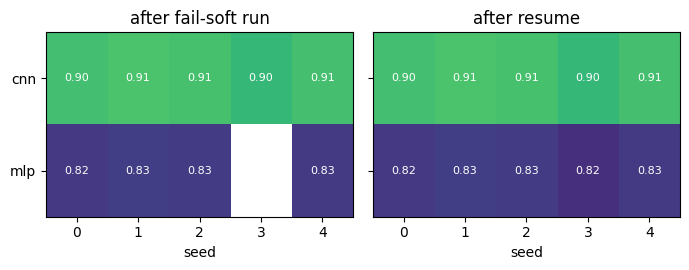

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=True)
for ax, ds, title in [
    (axes[0], ds_before, "after fail-soft run"),
    (axes[1], ds_after, "after resume"),
]:
    arr = ds["accuracy"].transpose("method", "seed").values
    im = ax.imshow(arr, vmin=0.8, vmax=0.95, cmap="viridis", aspect="auto")
    ax.set_xticks(range(ds.sizes["seed"]))
    ax.set_xticklabels(ds["seed"].values)
    ax.set_yticks(range(ds.sizes["method"]))
    ax.set_yticklabels(ds["method"].values)
    ax.set_xlabel("seed")
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            txt = "NaN" if np.isnan(arr[i, j]) else f"{arr[i, j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center", color="w", fontsize=8)
fig.tight_layout()
plt.show()

## 5. Now the comparison runs

With a complete grid, `compare_methods` returns a tidy pairwise-comparison
table (one row per metric × method-pair).

In [ ]:
compare_methods(ds_after)

/var/folders/y9/wzls976d3f9074y29dbrygw80000gn/T/ipykernel_25554/3332771622.py:1: UserWarning: test='wilcoxon' cannot reach alpha=0.05 with 5 seeds (best-case p=0.0625); use more seeds or a parametric test such as test='welch'.
  compare_methods(ds_after)


,metric,method_a,method_b,mean_diff,effect_size,p_value,p_corrected,significant
0,accuracy,cnn,mlp,0.08,27.939648,0.0625,0.0625,False


**See also**

- [Resilient & resumable sweeps guide](../guides/resilience.md) — provenance,
  `capture_env`, and the same options threaded through `Study`.